In [1]:
import os

print(os.listdir())

['.DS_Store', 'traintest.ipynb', 'datashow.ipynb', 'modeldevelopment.ipynb', 'data', 'lemon_leaf_dataset']


In [2]:
#Load Data
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_path = "lemon_leaf_dataset/train"
test_path = "lemon_leaf_dataset/test"

train_gen = ImageDataGenerator(rescale=1./255)
test_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_gen.flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 28123 images belonging to 2 classes.
Found 7045 images belonging to 2 classes.


In [3]:
#Build Model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# Layer 1
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))
model.add(MaxPooling2D(2,2))

# Layer 2
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Layer 3
model.add(Conv2D(128, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# Flatten
model.add(Flatten())

# Dense layers
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))

# OUTPUT LAYER (Binary)
model.add(Dense(1, activation='sigmoid'))

/Users/bhawanakc/Desktop/Lemon Leaf/Model/.venv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [4]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [5]:
#Train Model
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=20
)

Epoch 1/20
879/879 ━━━━━━━━━━━━━━━━━━━━ 416s 473ms/step - accuracy: 0.9847 - loss: 0.0426 - val_accuracy: 0.9959 - val_loss: 0.0244
Epoch 2/20
879/879 ━━━━━━━━━━━━━━━━━━━━ 646s 735ms/step - accuracy: 0.9937 - loss: 0.0200 - val_accuracy: 0.9980 - val_loss: 0.0061
Epoch 3/20
879/879 ━━━━━━━━━━━━━━━━━━━━ 742s 845ms/step - accuracy: 0.9980 - loss: 0.0057 - val_accuracy: 0.9994 - val_loss: 0.0023
Epoch 4/20
879/879 ━━━━━━━━━━━━━━━━━━━━ 750s 853ms/step - accuracy: 0.9963 - loss: 0.0126 - val_accuracy: 0.9991 - val_loss: 0.0038
Epoch 5/20
879/879 ━━━━━━━━━━━━━━━━━━━━ 1518s 2s/step - accuracy: 0.9969 - loss: 0.0138 - val_accuracy: 0.9976 - val_loss: 0.0079
Epoch 6/20
879/879 ━━━━━━━━━━━━━━━━━━━━ 695s 791ms/step - accuracy: 0.9983 - loss: 0.0054 - val_accuracy: 0.9991 - val_loss: 0.0025
Epoch 7/20
879/879 ━━━━━━━━━━━━━━━━━━━━ 757s 861ms/step - accuracy: 0.9987 - loss: 0.0052 - val_accuracy: 0.9990 - val_loss: 0.0025
Epoch 8/20
879/879 ━━━━━━━━━━━━━━━━━━━━ 591s 673ms/step - accuracy: 0.9982 - l

In [6]:
#save model
model.save("leaf_detector_model.keras")

In [7]:
#Evaluation model
loss, acc = model.evaluate(test_data)

print("Test Accuracy:", acc)
print("Test Loss:", loss)

221/221 ━━━━━━━━━━━━━━━━━━━━ 25s 112ms/step - accuracy: 0.9974 - loss: 0.0099
Test Accuracy: 0.9974449872970581
Test Loss: 0.009891274385154247


In [8]:
#load model 
from tensorflow.keras.models import load_model

model = load_model("leaf_detector_model.keras")

print("✅ Model Loaded Successfully")

✅ Model Loaded Successfully


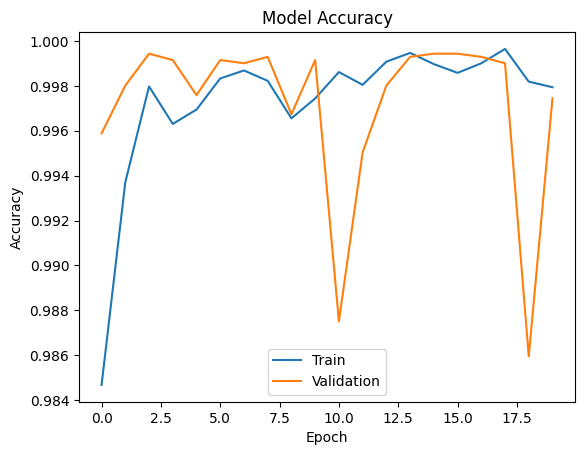

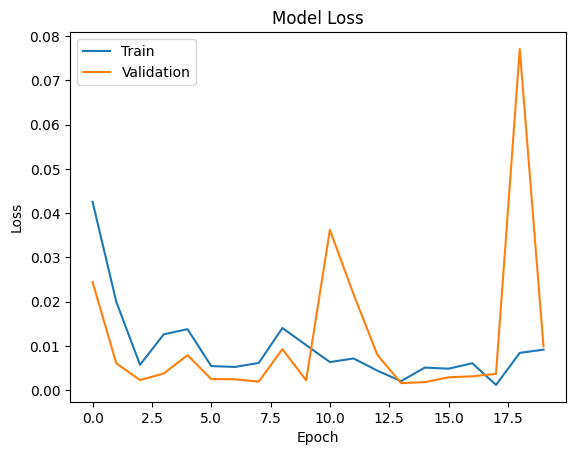

In [51]:
#Training performance graph
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

# Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train', 'Validation'])
plt.show()

In [52]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# predictions
y_pred = model.predict(test_data)
y_pred = (y_pred > 0.5).astype(int)

# true labels
y_true = test_data.classes

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred))

221/221 ━━━━━━━━━━━━━━━━━━━━ 24s 109ms/step
[[ 423 1308]
 [1292 4022]]
              precision    recall  f1-score   support

           0       0.25      0.24      0.25      1731
           1       0.75      0.76      0.76      5314

    accuracy                           0.63      7045
   macro avg       0.50      0.50      0.50      7045
weighted avg       0.63      0.63      0.63      7045



In [35]:
#prediction 
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model

model = load_model("leaf_detector_model.keras")

# FIX THIS after checking class_indices
class_names = {0: "lemon_leaf", 1: "not_lemon_leaf"}

def predict_image(img_path):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)[0][0]

    print("\nScore:", prediction)

    if prediction >= 0.5:
        label = "not_lemon_leaf"
    else:
        label = "lemon_leaf"

    print("Prediction:", label)

In [30]:
predict_image("/Users/bhawanakc/Downloads/data/21099.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [36]:
predict_image("/Users/bhawanakc/Downloads/data/21238.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [37]:
predict_image("/Users/bhawanakc/Downloads/data/21633.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [38]:
predict_image("/Users/bhawanakc/Downloads/data/21734.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [39]:
predict_image("/Users/bhawanakc/Downloads/data/21824.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [40]:
predict_image("/Users/bhawanakc/Downloads/data/22085.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [41]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Not_lemon_leaf_data/not_lemon_leaf_resized/airplane/airplane_0001.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [42]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Not_lemon_leaf_data/not_lemon_leaf_resized/car/car_0007.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [43]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Not_lemon_leaf_data/not_lemon_leaf_resized/Tomato__Target_Spot/0d97bbcf-f322-410a-984d-935e8d2bb5d0___Com.G_TgS_FL 0748.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [44]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Not_lemon_leaf_data/not_lemon_leaf_resized/Tomato_Septoria_leaf_spot/0d12d6ee-bc90-413e-8638-e476cd8ba8ee___Keller.St_CG 1840.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 1.0
Prediction: not_lemon_leaf


In [45]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Anthracnose/orig_RP_lemonleaf_resized_Anthracnose (179).jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 3.1955938e-09
Prediction: lemon_leaf


In [46]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Bacterial Blight/aug_Bacterial Blight_110.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 2.016798e-06
Prediction: lemon_leaf


In [47]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Bacterial Blight/aug_Bacterial Blight_173.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 3.365766e-05
Prediction: lemon_leaf


In [48]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Citrus Canker/aug_Citrus Canker_748.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 0.018622525
Prediction: lemon_leaf


In [49]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Curl Virus/aug_Curl Virus_759.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Score: 0.034130774
Prediction: lemon_leaf


In [50]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Deficiency Leaf/aug_Deficiency Leaf_756.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 3.615942e-08
Prediction: lemon_leaf


In [53]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Dry Leaf/aug_Dry Leaf_129.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

Score: 0.0001378978
Prediction: lemon_leaf


In [54]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Healthy Leaf/aug_Healthy Leaf_761.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 2.6082577e-16
Prediction: lemon_leaf


In [55]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Sooty Mould/aug_Sooty Mould_123.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Score: 3.4097086e-16
Prediction: lemon_leaf


In [56]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Spider Mites/aug_Spider Mites_129.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 1.6869046e-16
Prediction: lemon_leaf


In [57]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Spider Mites/orig_IEEE_lemonleaf_resized_spider_mites00114.JPG")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 4.8154184e-06
Prediction: lemon_leaf


In [58]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Sooty Mould/aug_Sooty Mould_151.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 5.8982347e-10
Prediction: lemon_leaf


In [59]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Dry Leaf/aug_Dry Leaf_207.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step

Score: 2.6706268e-06
Prediction: lemon_leaf


In [60]:
predict_image("/Users/bhawanakc/Desktop/Lemon Leaf/Data/Lemon_leaf_data/finaldataset/Dry Leaf/aug_Dry Leaf_284.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step

Score: 1.7633126e-07
Prediction: lemon_leaf
